In [4]:
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.neural_network import MLPRegressor, MLPClassifier
from xgboost import XGBClassifier
import shap
import joblib

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [17]:
import pandas as pd

df = pd.read_csv("../data/final_data.csv")

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", list(df.columns))

df.head()

Dataset loaded: 5000 rows × 23 columns
Columns: ['record_id', 'year', 'central_ministry', 'central_scheme', 'state', 'district', 'city', 'state_scheme', 'project_type', 'vendor_name', 'central_allocated_funds', 'state_received_funds', 'district_received_funds', 'project_budget', 'spent_amount', 'fund_utilization_rate', 'project_status', 'project_start_date', 'expected_completion', 'actual_completion', 'citizen_complaints', 'citizen_rating', 'completion_verified']


,record_id,year,central_ministry,central_scheme,state,district,city,state_scheme,project_type,vendor_name,...,project_budget,spent_amount,fund_utilization_rate,project_status,project_start_date,expected_completion,actual_completion,citizen_complaints,citizen_rating,completion_verified
0,1,2025,Ministry of Infrastructure,PM Awas Yojana,Uttar Pradesh,Kanpur,Kalyanpur,Urban Transport Improvement,Water Pipeline,Vendor_1024,...,33506669,12382766,0.370,Ongoing,11-01-2023,22-06-2023,27-07-2023,92,2.89,Yes
1,2,2024,Ministry of Education,Digital India,Gujarat,Vadodara,Alkapuri,Smart City Initiative,School Building,Vendor_1010,...,27371011,9823869,0.359,Delayed,05-02-2023,07-06-2023,30-07-2023,57,2.58,No
2,3,2024,Ministry of Rural Development,PM Awas Yojana,Gujarat,Vadodara,Alkapuri,Urban Housing Scheme,Road Construction,Vendor_1097,...,58994748,25672183,0.435,Completed,17-10-2023,20-02-2024,31-05-2024,33,4.48,Yes
3,4,2023,Ministry of Health,Ayushman Bharat,Maharashtra,Nashik,Panchavati,State Road Development,Bridge Development,Vendor_1076,...,44655093,10866580,0.243,Completed,25-03-2023,27-05-2023,17-05-2023,125,3.46,No
4,5,2025,Ministry of Health,PM Gram Sadak Yojana,Gujarat,Vadodara,Alkapuri,Urban Transport Improvement,Road Construction,Vendor_1022,...,70406896,43963701,0.624,Ongoing,23-08-2023,31-12-2023,16-04-2024,288,3.92,Yes


📊 EXPLORATORY DATA ANALYSIS

🔹 Shape: (5000, 23)

🔹 Data Types:
 record_id                    int64
year                         int64
central_ministry               str
central_scheme                 str
state                          str
district                       str
city                           str
state_scheme                   str
project_type                   str
vendor_name                    str
central_allocated_funds      int64
state_received_funds         int64
district_received_funds      int64
project_budget               int64
spent_amount                 int64
fund_utilization_rate      float64
project_status                 str
project_start_date             str
expected_completion            str
actual_completion              str
citizen_complaints           int64
citizen_rating             float64
completion_verified            str
dtype: object

🔹 Missing Values:
 record_id                  0
year                       0
central_ministry           0
central_s

,record_id,year,central_allocated_funds,state_received_funds,district_received_funds,project_budget,spent_amount,fund_utilization_rate,citizen_complaints,citizen_rating
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2500.500000,2023.993600,2.258663e+08,1.124277e+08,6.154985e+07,4.892746e+07,3.691249e+07,0.752349,150.518600,2.991086
std,1443.520003,0.815409,1.015149e+08,5.796208e+07,3.670176e+07,3.344242e+07,3.166108e+07,0.318604,86.733432,1.146612
min,1.000000,2023.000000,5.011794e+07,1.599125e+07,5.135031e+06,2.622453e+06,1.059413e+06,0.200000,0.000000,1.000000
25%,1250.750000,2023.000000,1.367988e+08,6.411437e+07,3.269459e+07,2.363956e+07,1.438546e+07,0.481750,74.000000,2.000000
50%,2500.500000,2024.000000,2.263566e+08,1.068468e+08,5.466849e+07,4.087852e+07,2.725964e+07,0.753500,152.000000,3.000000
75%,3750.250000,2025.000000,3.140812e+08,1.525293e+08,8.326665e+07,6.559735e+07,4.928741e+07,1.029000,226.000000,3.970000
max,5000.000000,2025.000000,3.999750e+08,2.748750e+08,2.135671e+08,2.416819e+08,2.690602e+08,1.300000,300.000000,5.000000


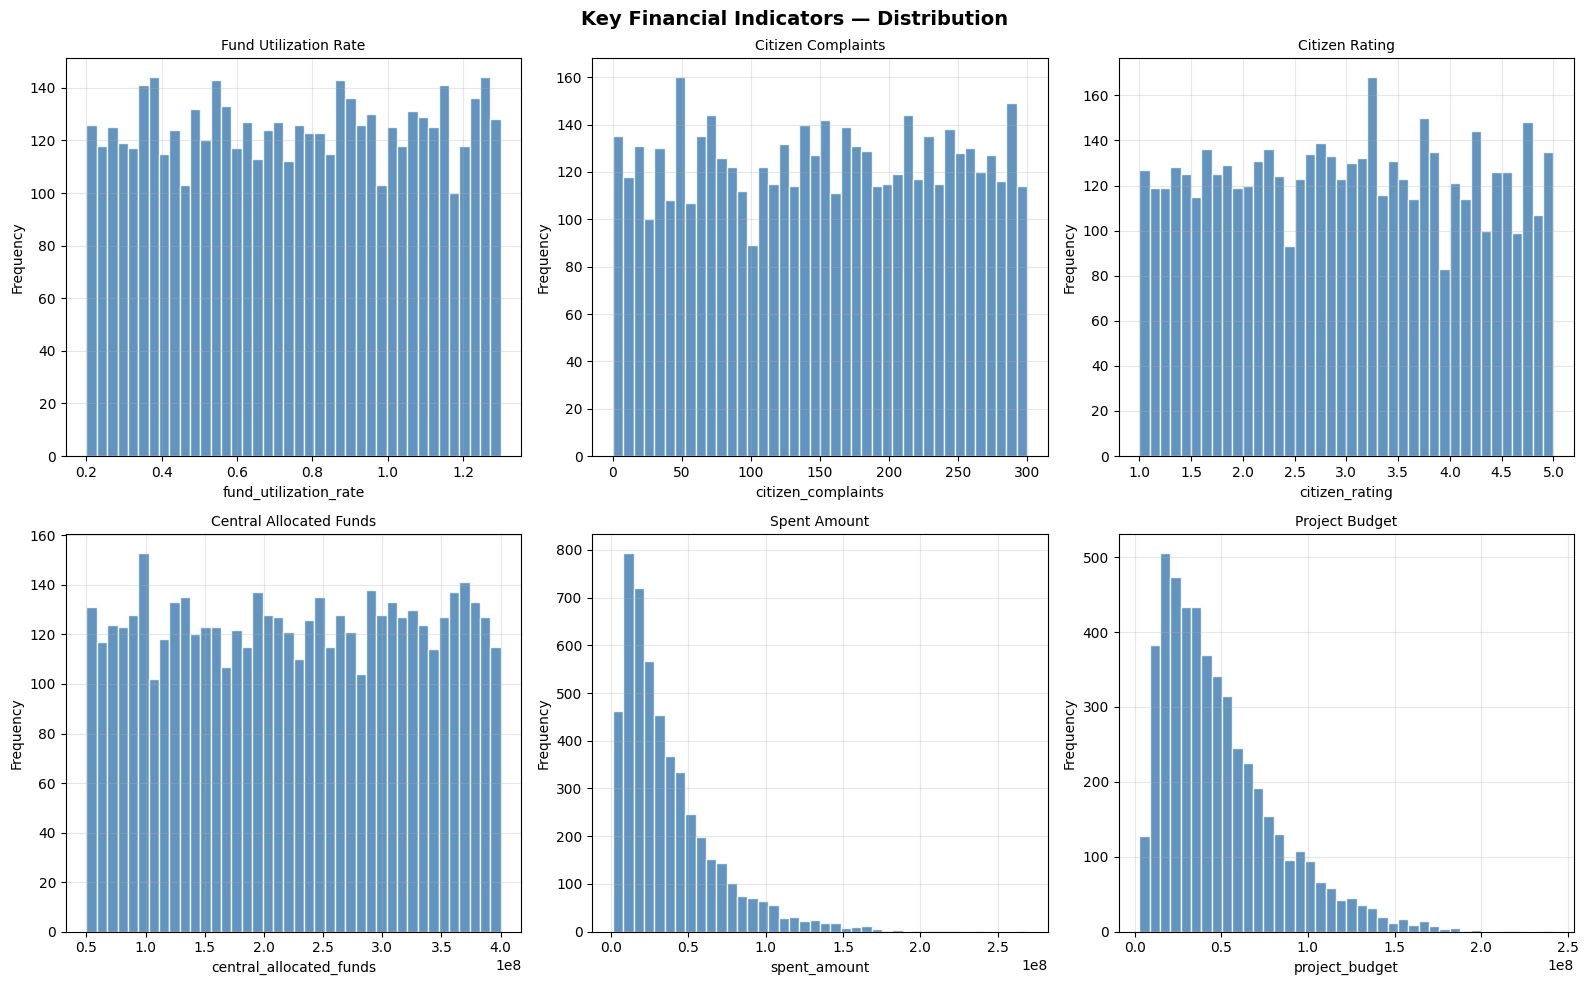

✅ EDA distributions saved


In [18]:
print("=" * 60)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\n🔹 Shape:", df.shape)
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Numeric Summary:")
display(df.describe())

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Financial Indicators — Distribution", fontsize=14, fontweight='bold')

numeric_cols = ['fund_utilization_rate', 'citizen_complaints', 'citizen_rating',
                'central_allocated_funds', 'spent_amount', 'project_budget']

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()
print("✅ EDA distributions saved")


In [19]:
print("=" * 60)
print("⚙️  FEATURE ENGINEERING  (Improved v2)")
print("=" * 60)

# ── Date features ──
df['project_start_date']  = pd.to_datetime(df['project_start_date'],  dayfirst=True, errors='coerce')
df['expected_completion'] = pd.to_datetime(df['expected_completion'],  dayfirst=True, errors='coerce')
df['actual_completion']   = pd.to_datetime(df['actual_completion'],    dayfirst=True, errors='coerce')

df['planned_duration_days'] = (df['expected_completion'] - df['project_start_date']).dt.days.fillna(0)
df['delay_days_raw']        = (df['actual_completion']   - df['expected_completion']).dt.days.fillna(0)

# ── BUG FIX 2: clip negative delays to 0 ──
# Projects finishing early get delay_days = 0 (not negative)
df['delay_days'] = df['delay_days_raw'].clip(lower=0)
df['is_delayed'] = (df['delay_days'] > 0).astype(int)
print(f"✅ BUG FIX 2 applied — negative delays clipped. "
      f"Early finishes: {(df['delay_days_raw'] < 0).sum()}")

# ── IMPROVEMENT 1: Central→State and State→District leakage gaps ──
# These detect mid-level fund diversion, not just end-to-end leakage
df['central_state_gap']    = (df['central_allocated_funds'] - df['state_received_funds']).clip(lower=0)
df['state_district_gap']   = (df['state_received_funds']    - df['district_received_funds']).clip(lower=0)
df['central_state_gap_pct']    = (df['central_state_gap']  / df['central_allocated_funds'].replace(0, np.nan)).fillna(0).clip(0, 1)
df['state_district_gap_pct']   = (df['state_district_gap'] / df['state_received_funds'].replace(0, np.nan)).fillna(0).clip(0, 1)

# Overall Central→District leakage (kept for backward compat)
df['fund_leakage']     = df['central_allocated_funds'] - df['district_received_funds']
df['fund_leakage_pct'] = (df['fund_leakage'] / df['central_allocated_funds'].replace(0, np.nan)).fillna(0).clip(0, 1)

df['state_absorption_rate']    = (df['state_received_funds']    / df['central_allocated_funds'].replace(0, np.nan)).fillna(0)
df['district_absorption_rate'] = (df['district_received_funds'] / df['state_received_funds'].replace(0, np.nan)).fillna(0)

print(f"✅ IMPROVEMENT 1 — Central→State gap avg: ₹{df['central_state_gap'].mean():,.0f} | "
      f"State→District gap avg: ₹{df['state_district_gap'].mean():,.0f}")

# ── Spending features ──
df['overspend']         = (df['spent_amount'] > df['project_budget']).astype(int)
df['underutilized']     = (df['fund_utilization_rate'] < 0.4).astype(int)
df['budget_efficiency'] = (df['spent_amount'] / df['project_budget'].replace(0, np.nan)).fillna(0)

# ── Citizen feedback features ──
df['citizen_risk']    = ((df['citizen_complaints'] > 100) & (df['citizen_rating'] < 2.5)).astype(int)
df['false_completion']= ((df['project_status'] == 'Completed') & (df['completion_verified'] == 'No')).astype(int)

# ── BUG FIX 1: Vendor concentration — safe index-aligned calculation ──
vendor_counts   = df.groupby(['district', 'vendor_name']).size()
district_counts = df.groupby('district').size()

df['vendor_concentration'] = df.apply(
    lambda x: vendor_counts.get((x['district'], x['vendor_name']), 0) /
              district_counts.get(x['district'], 1),
    axis=1
)
print(f"✅ BUG FIX 1 applied — vendor concentration recalculated safely. "
      f"Max concentration: {df['vendor_concentration'].max():.3f}")

# ── IMPROVEMENT 4: Normalize helper ──
def normalize(col):
    rng = col.max() - col.min()
    return (col - col.min()) / rng if rng > 0 else col * 0

# ── Composite Rule-Based Risk Score (using normalized components) ──
df['risk_score'] = (
    0.20 * ((df['fund_utilization_rate'] < 0.3) | (df['fund_utilization_rate'] > 1.1)).astype(int) +
    0.15 * (df['delay_days'] > 60).astype(int) +
    0.15 * df['citizen_risk'] +
    0.15 * df['vendor_concentration'].clip(0, 1) +
    0.10 * df['overspend'] +
    0.10 * df['false_completion'] +
    0.08 * (df['fund_leakage_pct'] > 0.5).astype(int) +
    0.05 * (df['central_state_gap_pct'] > 0.2).astype(int) +   # IMPROVEMENT 1
    0.02 * (df['state_district_gap_pct'] > 0.3).astype(int) +  # IMPROVEMENT 1
    0.05 * df['is_delayed']
)

df['risk_norm']  = normalize(df['risk_score'])   # IMPROVEMENT 4
print(f"✅ IMPROVEMENT 4 — Risk score normalized to [0, 1]")

df['risk_label'] = pd.cut(df['risk_score'], bins=[-0.01, 0.3, 0.6, 1.01],
                           labels=['Low', 'Medium', 'High'])
df['lapse_risk'] = (df['fund_utilization_rate'] < 0.5).astype(int)

print(f"\n✅ Features engineered. New shape: {df.shape}")
print(f"\n📊 Risk Label Distribution:\n{df['risk_label'].value_counts()}")
print(f"\n📊 Lapse Risk (target):\n{df['lapse_risk'].value_counts()}")



⚙️  FEATURE ENGINEERING  (Improved v2)
✅ BUG FIX 2 applied — negative delays clipped. Early finishes: 966
✅ IMPROVEMENT 1 — Central→State gap avg: ₹113,438,618 | State→District gap avg: ₹50,877,871
✅ BUG FIX 1 applied — vendor concentration recalculated safely. Max concentration: 0.036
✅ IMPROVEMENT 4 — Risk score normalized to [0, 1]

✅ Features engineered. New shape: (5000, 45)

📊 Risk Label Distribution:
risk_label
Medium    2917
Low       1411
High       672
Name: count, dtype: int64

📊 Lapse Risk (target):
lapse_risk
0    3646
1    1354
Name: count, dtype: int64


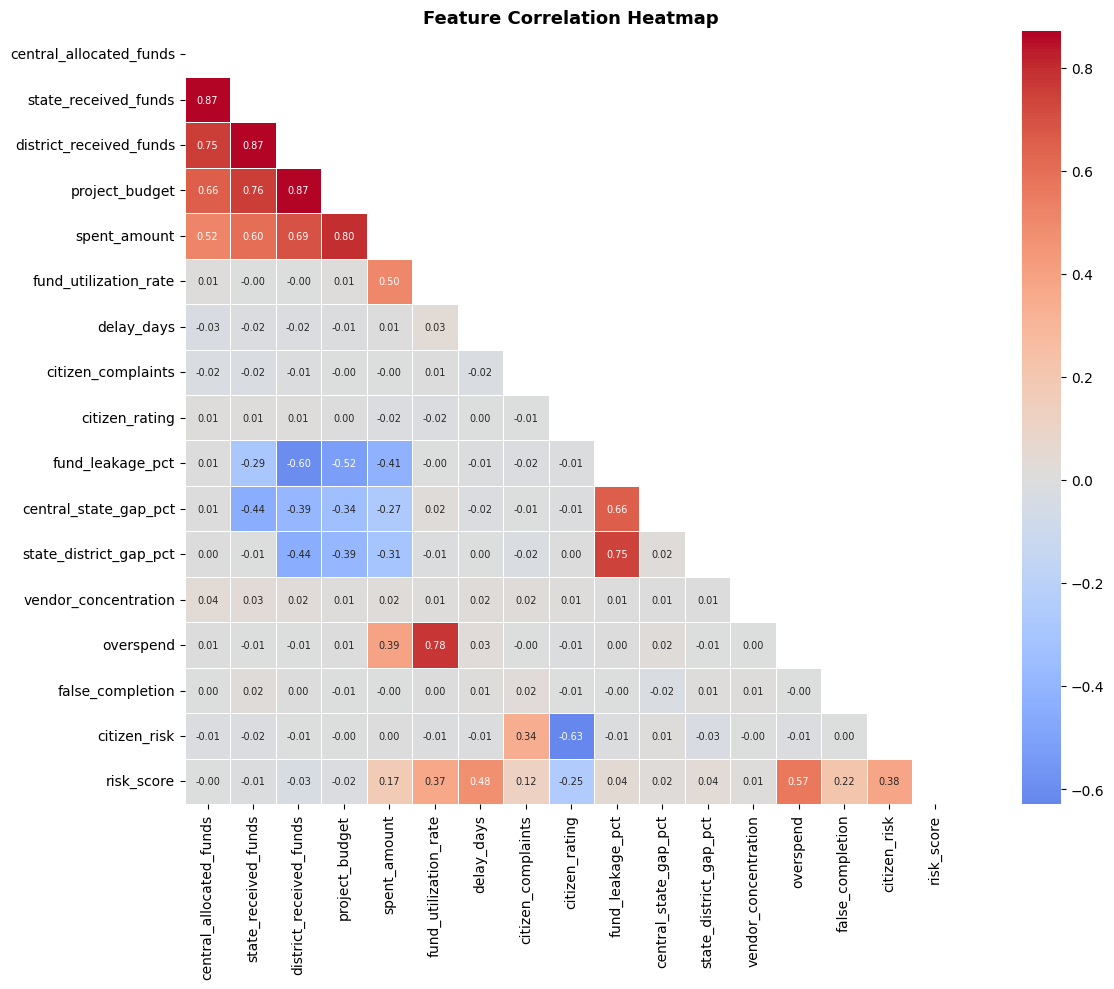

✅ Correlation heatmap saved


In [20]:
feature_cols = [
    'central_allocated_funds', 'state_received_funds', 'district_received_funds',
    'project_budget', 'spent_amount', 'fund_utilization_rate',
    'delay_days', 'citizen_complaints', 'citizen_rating',
    'fund_leakage_pct', 'central_state_gap_pct', 'state_district_gap_pct',
    'vendor_concentration', 'overspend',
    'false_completion', 'citizen_risk', 'risk_score'
]

plt.figure(figsize=(14, 10))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved")



In [21]:
ML_FEATURES = [
    'central_allocated_funds', 'state_received_funds', 'district_received_funds',
    'project_budget', 'spent_amount', 'fund_utilization_rate',
    'delay_days', 'citizen_complaints', 'citizen_rating',
    'fund_leakage_pct',
    'central_state_gap_pct',       # IMPROVEMENT 1 — Central→State leakage signal
    'state_district_gap_pct',      # IMPROVEMENT 1 — State→District leakage signal
    'vendor_concentration',
    'state_absorption_rate', 'district_absorption_rate',
    'budget_efficiency', 'planned_duration_days',
    'overspend', 'underutilized', 'citizen_risk', 'false_completion'
]

X = df[ML_FEATURES].fillna(0)
y = df['lapse_risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=ML_FEATURES)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Feature matrix ready: {X.shape}")
print(f"   Train: {X_train.shape} | Test: {X_test.shape}")
print(f"   Target distribution — Lapse(1): {y.sum()} | Normal(0): {(y==0).sum()}")



✅ Feature matrix ready: (5000, 21)
   Train: (4000, 21) | Test: (1000, 21)
   Target distribution — Lapse(1): 1354 | Normal(0): 3646


🧠 MODEL 1: DENSE AUTOENCODER  (64 → 32 → 8 → 32 → 64)
   Improvement 2: deeper bottleneck (8) forces better compression
⏳ Training Autoencoder...

✅ Autoencoder trained | Reconstruction Error Threshold (P90): 0.1591
   Anomalies Detected: 500 / 5000


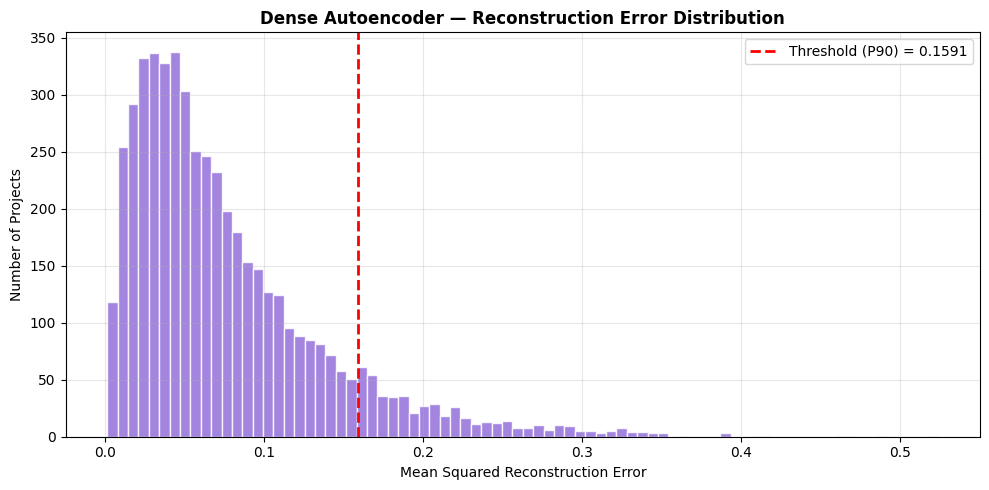

In [22]:
print("=" * 60)
print("🧠 MODEL 1: DENSE AUTOENCODER  (64 → 32 → 8 → 32 → 64)")
print("=" * 60)
print("   Improvement 2: deeper bottleneck (8) forces better compression")

autoencoder = MLPRegressor(
    hidden_layer_sizes=(64, 32, 8, 32, 64),  # IMPROVEMENT 2: 64→32→8→32→64
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    verbose=False
)

print("⏳ Training Autoencoder...")
autoencoder.fit(X_scaled, X_scaled)

X_recon         = autoencoder.predict(X_scaled)
recon_errors    = np.mean((X_scaled - X_recon) ** 2, axis=1)
ae_threshold    = np.percentile(recon_errors, 90)  # top 10% = anomalies

df['ae_recon_error'] = recon_errors
df['ae_anomaly']     = (recon_errors > ae_threshold).astype(int)

print(f"\n✅ Autoencoder trained | Reconstruction Error Threshold (P90): {ae_threshold:.4f}")
print(f"   Anomalies Detected: {df['ae_anomaly'].sum()} / {len(df)}")

# ── Plot reconstruction error distribution ──
plt.figure(figsize=(10, 5))
plt.hist(recon_errors, bins=80, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.axvline(ae_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (P90) = {ae_threshold:.4f}')
plt.title('Dense Autoencoder — Reconstruction Error Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Mean Squared Reconstruction Error')
plt.ylabel('Number of Projects')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("autoencoder_recon_error.png", dpi=150)
plt.show()



🌲 MODEL 2: ISOLATION FOREST  (contamination = 0.05)
   Improvement 3: 5% contamination — corruption is rare, not 10%
⏳ Training Isolation Forest...

✅ Isolation Forest trained
   Anomalies Detected: 250 / 5000


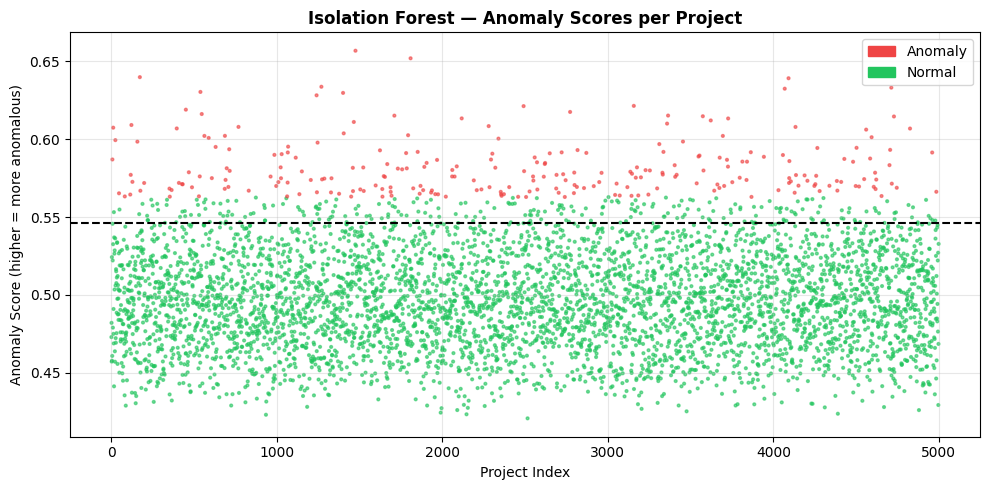

In [23]:
print("=" * 60)
print("🌲 MODEL 2: ISOLATION FOREST  (contamination = 0.05)")
print("=" * 60)
print("   Improvement 3: 5% contamination — corruption is rare, not 10%")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # IMPROVEMENT 3: was 0.10, now 0.05 (more precise)
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("⏳ Training Isolation Forest...")
iso_forest.fit(X_scaled)

iso_preds          = iso_forest.predict(X_scaled)
iso_scores         = -iso_forest.score_samples(X_scaled)  # higher = more anomalous

df['iso_anomaly']  = (iso_preds == -1).astype(int)
df['iso_score']    = iso_scores

print(f"\n✅ Isolation Forest trained")
print(f"   Anomalies Detected: {df['iso_anomaly'].sum()} / {len(df)}")

# ── Plot isolation scores ──
plt.figure(figsize=(10, 5))
colors = ['#ef4444' if a == 1 else '#22c55e' for a in df['iso_anomaly']]
plt.scatter(range(len(df)), iso_scores, c=colors, s=4, alpha=0.6)
plt.axhline(np.percentile(iso_scores, 90), color='black', linestyle='--',
            linewidth=1.5, label='P90 Score Threshold')
plt.title('Isolation Forest — Anomaly Scores per Project', fontsize=12, fontweight='bold')
plt.xlabel('Project Index')
plt.ylabel('Anomaly Score (higher = more anomalous)')
red_patch   = mpatches.Patch(color='#ef4444', label='Anomaly')
green_patch = mpatches.Patch(color='#22c55e', label='Normal')
plt.legend(handles=[red_patch, green_patch])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("isolation_forest_scores.png", dpi=150)
plt.show()

🎯 MODEL 3: RANDOM FOREST CLASSIFIER (Lapse Prediction)
⏳ Training Random Forest...

✅ Random Forest trained

📊 Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       729
  Lapse Risk       1.00      1.00      1.00       271

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

📊 ROC-AUC Score:  1.0000
📊 CV ROC-AUC:     1.0000 ± 0.0000


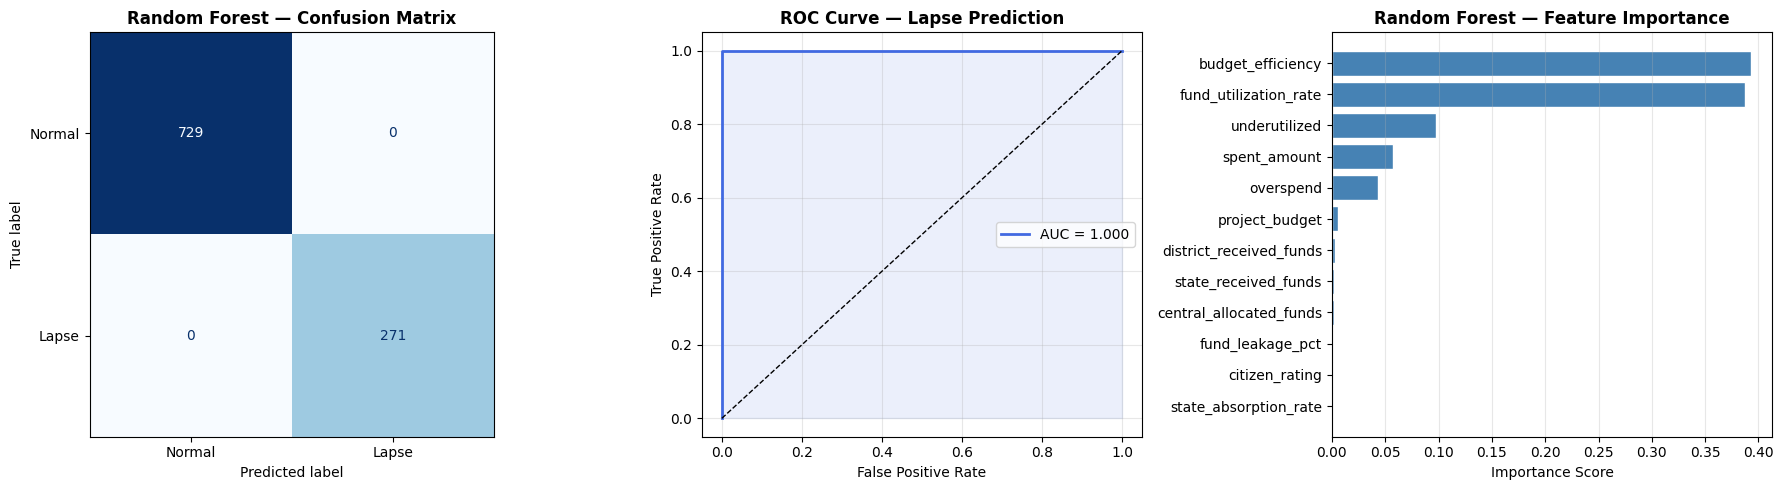

In [24]:
print("=" * 60)
print("🎯 MODEL 3: RANDOM FOREST CLASSIFIER (Lapse Prediction)")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("⏳ Training Random Forest...")
rf_model.fit(X_train, y_train)

rf_preds     = rf_model.predict(X_test)
rf_proba     = rf_model.predict_proba(X_test)[:, 1]
df['lapse_probability'] = rf_model.predict_proba(X_scaled)[:, 1]

# Cross-validation
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='roc_auc', n_jobs=-1)

print(f"\n✅ Random Forest trained")
print(f"\n📊 Classification Report:\n")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Lapse Risk']))
print(f"📊 ROC-AUC Score:  {roc_auc_score(y_test, rf_proba):.4f}")
print(f"📊 CV ROC-AUC:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Plots: Confusion Matrix + ROC Curve + Feature Importance ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds),
                       display_labels=['Normal', 'Lapse']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc_val = roc_auc_score(y_test, rf_proba)
axes[1].plot(fpr, tpr, color='royalblue', linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='royalblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Lapse Prediction', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature Importance
fi_df = pd.DataFrame({'feature': ML_FEATURES, 'importance': rf_model.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True).tail(12)
axes[2].barh(fi_df['feature'], fi_df['importance'], color='steelblue', edgecolor='white')
axes[2].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("random_forest_results.png", dpi=150)
plt.show()


In [25]:
print("=" * 60)
print("⚡ MODEL 4: XGBoost CLASSIFIER (Anomaly Flag Prediction)")
print("=" * 60)

# Use iso_anomaly as target for XGBoost
y_xgb = df['iso_anomaly']
X_tr_xgb, X_te_xgb, y_tr_xgb, y_te_xgb = train_test_split(
    X_scaled, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

print("⏳ Training XGBoost...")
xgb_model.fit(X_tr_xgb, y_tr_xgb,
              eval_set=[(X_te_xgb, y_te_xgb)],
              verbose=False)

xgb_preds = xgb_model.predict(X_te_xgb)
xgb_proba = xgb_model.predict_proba(X_te_xgb)[:, 1]
df['xgb_anomaly_prob'] = xgb_model.predict_proba(X_scaled)[:, 1]

print(f"\n✅ XGBoost trained")
print(f"\n📊 Classification Report:\n")
print(classification_report(y_te_xgb, xgb_preds, target_names=['Normal', 'Anomaly']))
print(f"📊 ROC-AUC: {roc_auc_score(y_te_xgb, xgb_proba):.4f}")


⚡ MODEL 4: XGBoost CLASSIFIER (Anomaly Flag Prediction)
⏳ Training XGBoost...

✅ XGBoost trained

📊 Classification Report:

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       950
     Anomaly       0.91      0.62      0.74        50

    accuracy                           0.98      1000
   macro avg       0.95      0.81      0.86      1000
weighted avg       0.98      0.98      0.98      1000

📊 ROC-AUC: 0.9916


📐 COMBINED RISK SCORE  (Normalized + Vendor Risk)
✅ IMPROVEMENT 4 — All components normalized before combining

🏗️  IMPROVEMENT 5 — Vendor Risk Analysis

   Top 10 High-Risk Vendors:


,vendor_name,total_projects,avg_final_risk,high_risk_projects,iso_anomalies,false_completions,vendor_risk_score,vendor_risk_label
42,Vendor_1042,54,0.342,2,10,13,0.918,High
7,Vendor_1007,52,0.293,2,4,10,0.654,High
57,Vendor_1057,61,0.297,1,3,16,0.601,High
79,Vendor_1079,47,0.297,2,3,6,0.543,Medium
44,Vendor_1044,59,0.298,1,4,11,0.539,Medium
30,Vendor_1030,54,0.309,1,3,12,0.534,Medium
64,Vendor_1064,46,0.301,1,4,8,0.531,Medium
63,Vendor_1063,46,0.284,2,2,6,0.530,Medium
69,Vendor_1069,58,0.287,1,4,14,0.521,Medium
53,Vendor_1053,48,0.316,1,3,7,0.504,Medium


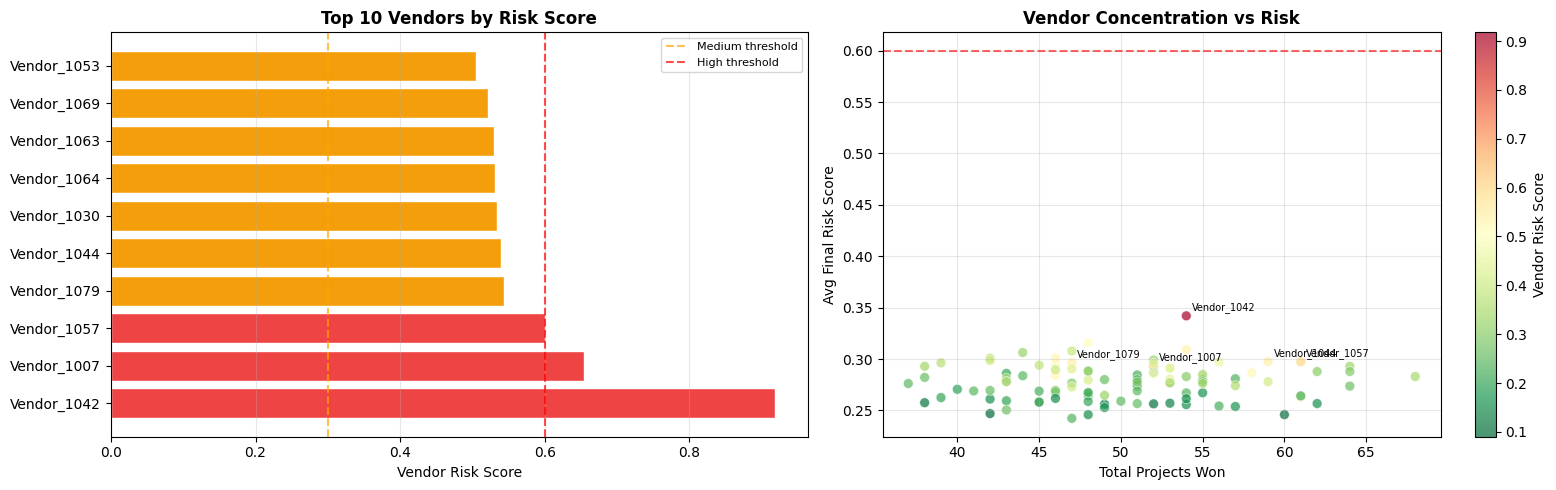

✅ IMPROVEMENT 5 — Vendor risk chart saved

✅ Final Risk Score computed for all 5000 projects

📊 Final Risk Distribution:
final_risk_label
Low       2989
Medium    1978
High        33
Name: count, dtype: int64

🔴 HIGH RISK PROJECTS: 33
🟡 MEDIUM RISK:        1978
🟢 LOW RISK:           2989
🔍 IMPROVEMENT 6: SHAP — Explainable AI
   WHY was each project flagged as high risk?


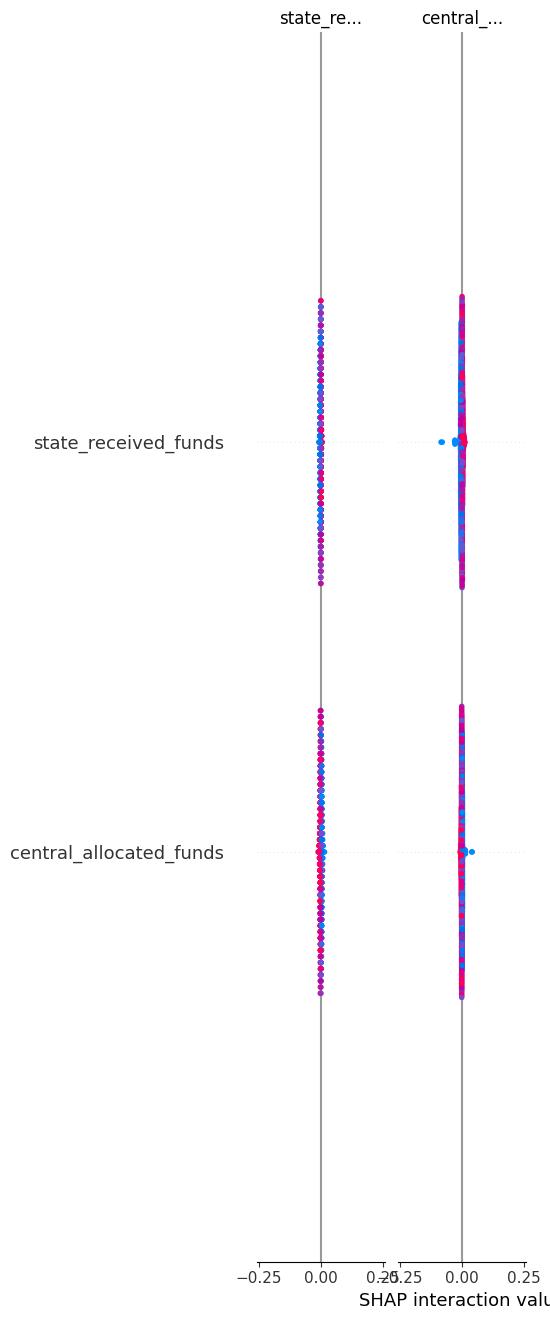

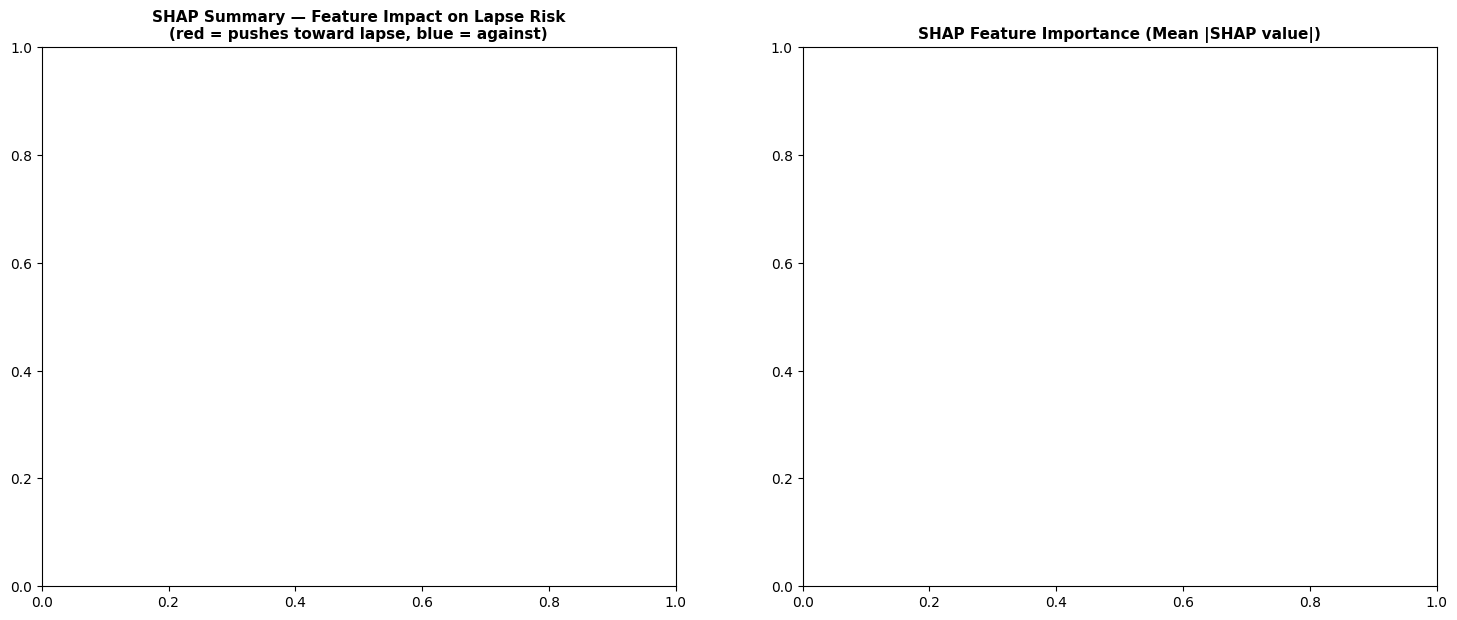

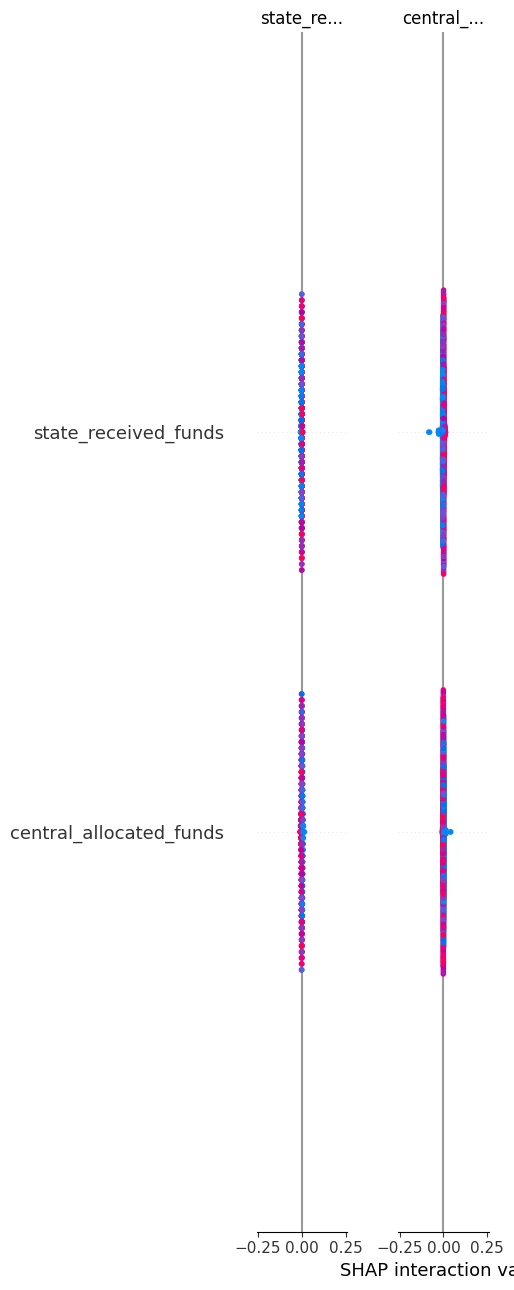

✅ SHAP charts saved → shap_explainability.png

🔍 Example — Explaining the HIGHEST RISK project:
   Project Record ID : 1975
   State             : Tamil Nadu
   District          : Chennai
   Final Risk Score  : 0.715

   Top SHAP drivers for this project:


,Feature,SHAP Value,Direction
10,central_state_gap_pct,-0.194205,↓ Reduces Risk
11,state_district_gap_pct,0.194205,↑ Increases Risk
8,citizen_rating,-0.030981,↓ Reduces Risk
9,fund_leakage_pct,0.030981,↑ Increases Risk
20,false_completion,0.004324,↑ Increases Risk
6,delay_days,0.002189,↑ Increases Risk
7,citizen_complaints,-0.002189,↓ Reduces Risk
19,citizen_risk,-0.000691,↓ Reduces Risk


In [26]:
print("=" * 60)
print("📐 COMBINED RISK SCORE  (Normalized + Vendor Risk)")
print("=" * 60)

# ── IMPROVEMENT 4: Normalize each ML signal to [0, 1] before combining ──
ae_norm  = normalize(df['ae_recon_error'])
iso_norm = normalize(df['iso_score'])

df['final_risk_score'] = (
    0.35 * df['risk_norm'] +           # Rule-based (already normalized)
    0.20 * ae_norm +                   # Autoencoder signal (normalized)
    0.20 * iso_norm +                  # Isolation Forest signal (normalized)
    0.15 * df['lapse_probability'] +   # Random Forest lapse probability
    0.10 * df['xgb_anomaly_prob']      # XGBoost anomaly probability
).clip(0, 1)

print("✅ IMPROVEMENT 4 — All components normalized before combining")

df['final_risk_label'] = pd.cut(
    df['final_risk_score'],
    bins=[-0.01, 0.3, 0.6, 1.01],
    labels=['Low', 'Medium', 'High']
)

# ── IMPROVEMENT 5: Vendor Risk Detection ──
print("\n🏗️  IMPROVEMENT 5 — Vendor Risk Analysis")
vendor_risk = df.groupby('vendor_name').agg(
    total_projects     = ('record_id', 'count'),
    avg_final_risk     = ('final_risk_score', 'mean'),
    high_risk_projects = ('final_risk_score', lambda x: (x > 0.6).sum()),
    iso_anomalies      = ('iso_anomaly', 'sum'),
    false_completions  = ('false_completion', 'sum'),
    avg_utilization    = ('fund_utilization_rate', 'mean'),
    total_allocated    = ('central_allocated_funds', 'sum'),
    avg_delay_days     = ('delay_days', 'mean'),
    avg_citizen_rating = ('citizen_rating', 'mean'),
).reset_index()

vendor_risk['vendor_risk_score'] = (
    0.30 * normalize(vendor_risk['avg_final_risk']) +
    0.25 * normalize(vendor_risk['high_risk_projects']) +
    0.20 * normalize(vendor_risk['iso_anomalies']) +
    0.15 * normalize(vendor_risk['false_completions']) +
    0.10 * normalize(vendor_risk['avg_delay_days'])
).clip(0, 1)

vendor_risk['vendor_risk_label'] = pd.cut(
    vendor_risk['vendor_risk_score'],
    bins=[-0.01, 0.3, 0.6, 1.01],
    labels=['Low', 'Medium', 'High']
)

top_vendors = vendor_risk.sort_values('vendor_risk_score', ascending=False).head(10)

print(f"\n   Top 10 High-Risk Vendors:")
display(top_vendors[['vendor_name', 'total_projects', 'avg_final_risk',
                      'high_risk_projects', 'iso_anomalies', 'false_completions',
                      'vendor_risk_score', 'vendor_risk_label']].round(3))

# ── Vendor Risk Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — top vendor risk scores
colors_v = ['#ef4444' if s > 0.6 else '#f59e0b' if s > 0.3 else '#22c55e'
            for s in top_vendors['vendor_risk_score']]
axes[0].barh(top_vendors['vendor_name'], top_vendors['vendor_risk_score'],
             color=colors_v, edgecolor='white')
axes[0].set_title('Top 10 Vendors by Risk Score', fontweight='bold')
axes[0].set_xlabel('Vendor Risk Score')
axes[0].axvline(0.3, color='orange', linestyle='--', alpha=0.7, label='Medium threshold')
axes[0].axvline(0.6, color='red',    linestyle='--', alpha=0.7, label='High threshold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Scatter — projects vs avg risk
sc = axes[1].scatter(vendor_risk['total_projects'], vendor_risk['avg_final_risk'],
                     c=vendor_risk['vendor_risk_score'], cmap='RdYlGn_r',
                     s=50, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label='Vendor Risk Score')
axes[1].set_xlabel('Total Projects Won')
axes[1].set_ylabel('Avg Final Risk Score')
axes[1].set_title('Vendor Concentration vs Risk', fontweight='bold')
axes[1].axhline(0.6, color='red', linestyle='--', alpha=0.6)
axes[1].grid(True, alpha=0.3)

for _, row in top_vendors.head(5).iterrows():
    axes[1].annotate(row['vendor_name'], (row['total_projects'], row['avg_final_risk']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')

plt.tight_layout()
plt.savefig("vendor_risk_analysis.png", dpi=150)
plt.show()
print("✅ IMPROVEMENT 5 — Vendor risk chart saved")

print(f"\n✅ Final Risk Score computed for all {len(df)} projects")
print(f"\n📊 Final Risk Distribution:\n{df['final_risk_label'].value_counts()}")
print(f"\n🔴 HIGH RISK PROJECTS: {(df['final_risk_label']=='High').sum()}")
print(f"🟡 MEDIUM RISK:        {(df['final_risk_label']=='Medium').sum()}")
print(f"🟢 LOW RISK:           {(df['final_risk_label']=='Low').sum()}")


# ─────────────────────────────────────────────────────────────
# CELL 11b — IMPROVEMENT 6: SHAP Explainability (XAI)
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("🔍 IMPROVEMENT 6: SHAP — Explainable AI")
print("   WHY was each project flagged as high risk?")
print("=" * 60)

# Use Random Forest on test set for SHAP
explainer    = shap.TreeExplainer(rf_model)
shap_values  = explainer.shap_values(X_test)

# shap_values is a list [class0, class1] for binary classifier
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Plot 1: Summary beeswarm (global feature importance) ──
plt.sca(axes[0])
shap.summary_plot(sv, X_test, feature_names=ML_FEATURES,
                  plot_type='dot', show=False, max_display=15)
axes[0].set_title('SHAP Summary — Feature Impact on Lapse Risk\n(red = pushes toward lapse, blue = against)',
                   fontsize=11, fontweight='bold')

# ── Plot 2: Bar chart (mean |SHAP| per feature) ──
plt.sca(axes[1])
shap.summary_plot(sv, X_test, feature_names=ML_FEATURES,
                  plot_type='bar', show=False, max_display=15)
axes[1].set_title('SHAP Feature Importance (Mean |SHAP value|)',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("shap_explainability.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP charts saved → shap_explainability.png")

# ── Single project explanation example ──
print("\n🔍 Example — Explaining the HIGHEST RISK project:")

highest_idx = df['final_risk_score'].idxmax()

X_example = X_scaled[highest_idx:highest_idx+1]

sv_example = explainer.shap_values(X_example)

# Handle SHAP output shape safely
sv_ex = sv_example[1] if isinstance(sv_example, list) else sv_example
sv_ex = np.array(sv_ex).reshape(-1)   # ensure 1D array

# Ensure same length as features
sv_ex = sv_ex[:len(ML_FEATURES)]

print(f"   Project Record ID : {df.loc[highest_idx, 'record_id']}")
print(f"   State             : {df.loc[highest_idx, 'state']}")
print(f"   District          : {df.loc[highest_idx, 'district']}")
print(f"   Final Risk Score  : {df.loc[highest_idx, 'final_risk_score']:.3f}")

print("\n   Top SHAP drivers for this project:")

shap_df = pd.DataFrame({
    'Feature': ML_FEATURES,
    'SHAP Value': sv_ex
})

shap_df['Direction'] = shap_df['SHAP Value'].apply(
    lambda v: "↑ Increases Risk" if v > 0 else "↓ Reduces Risk"
)

shap_df = shap_df.sort_values('SHAP Value', key=abs, ascending=False).head(8)

display(shap_df)

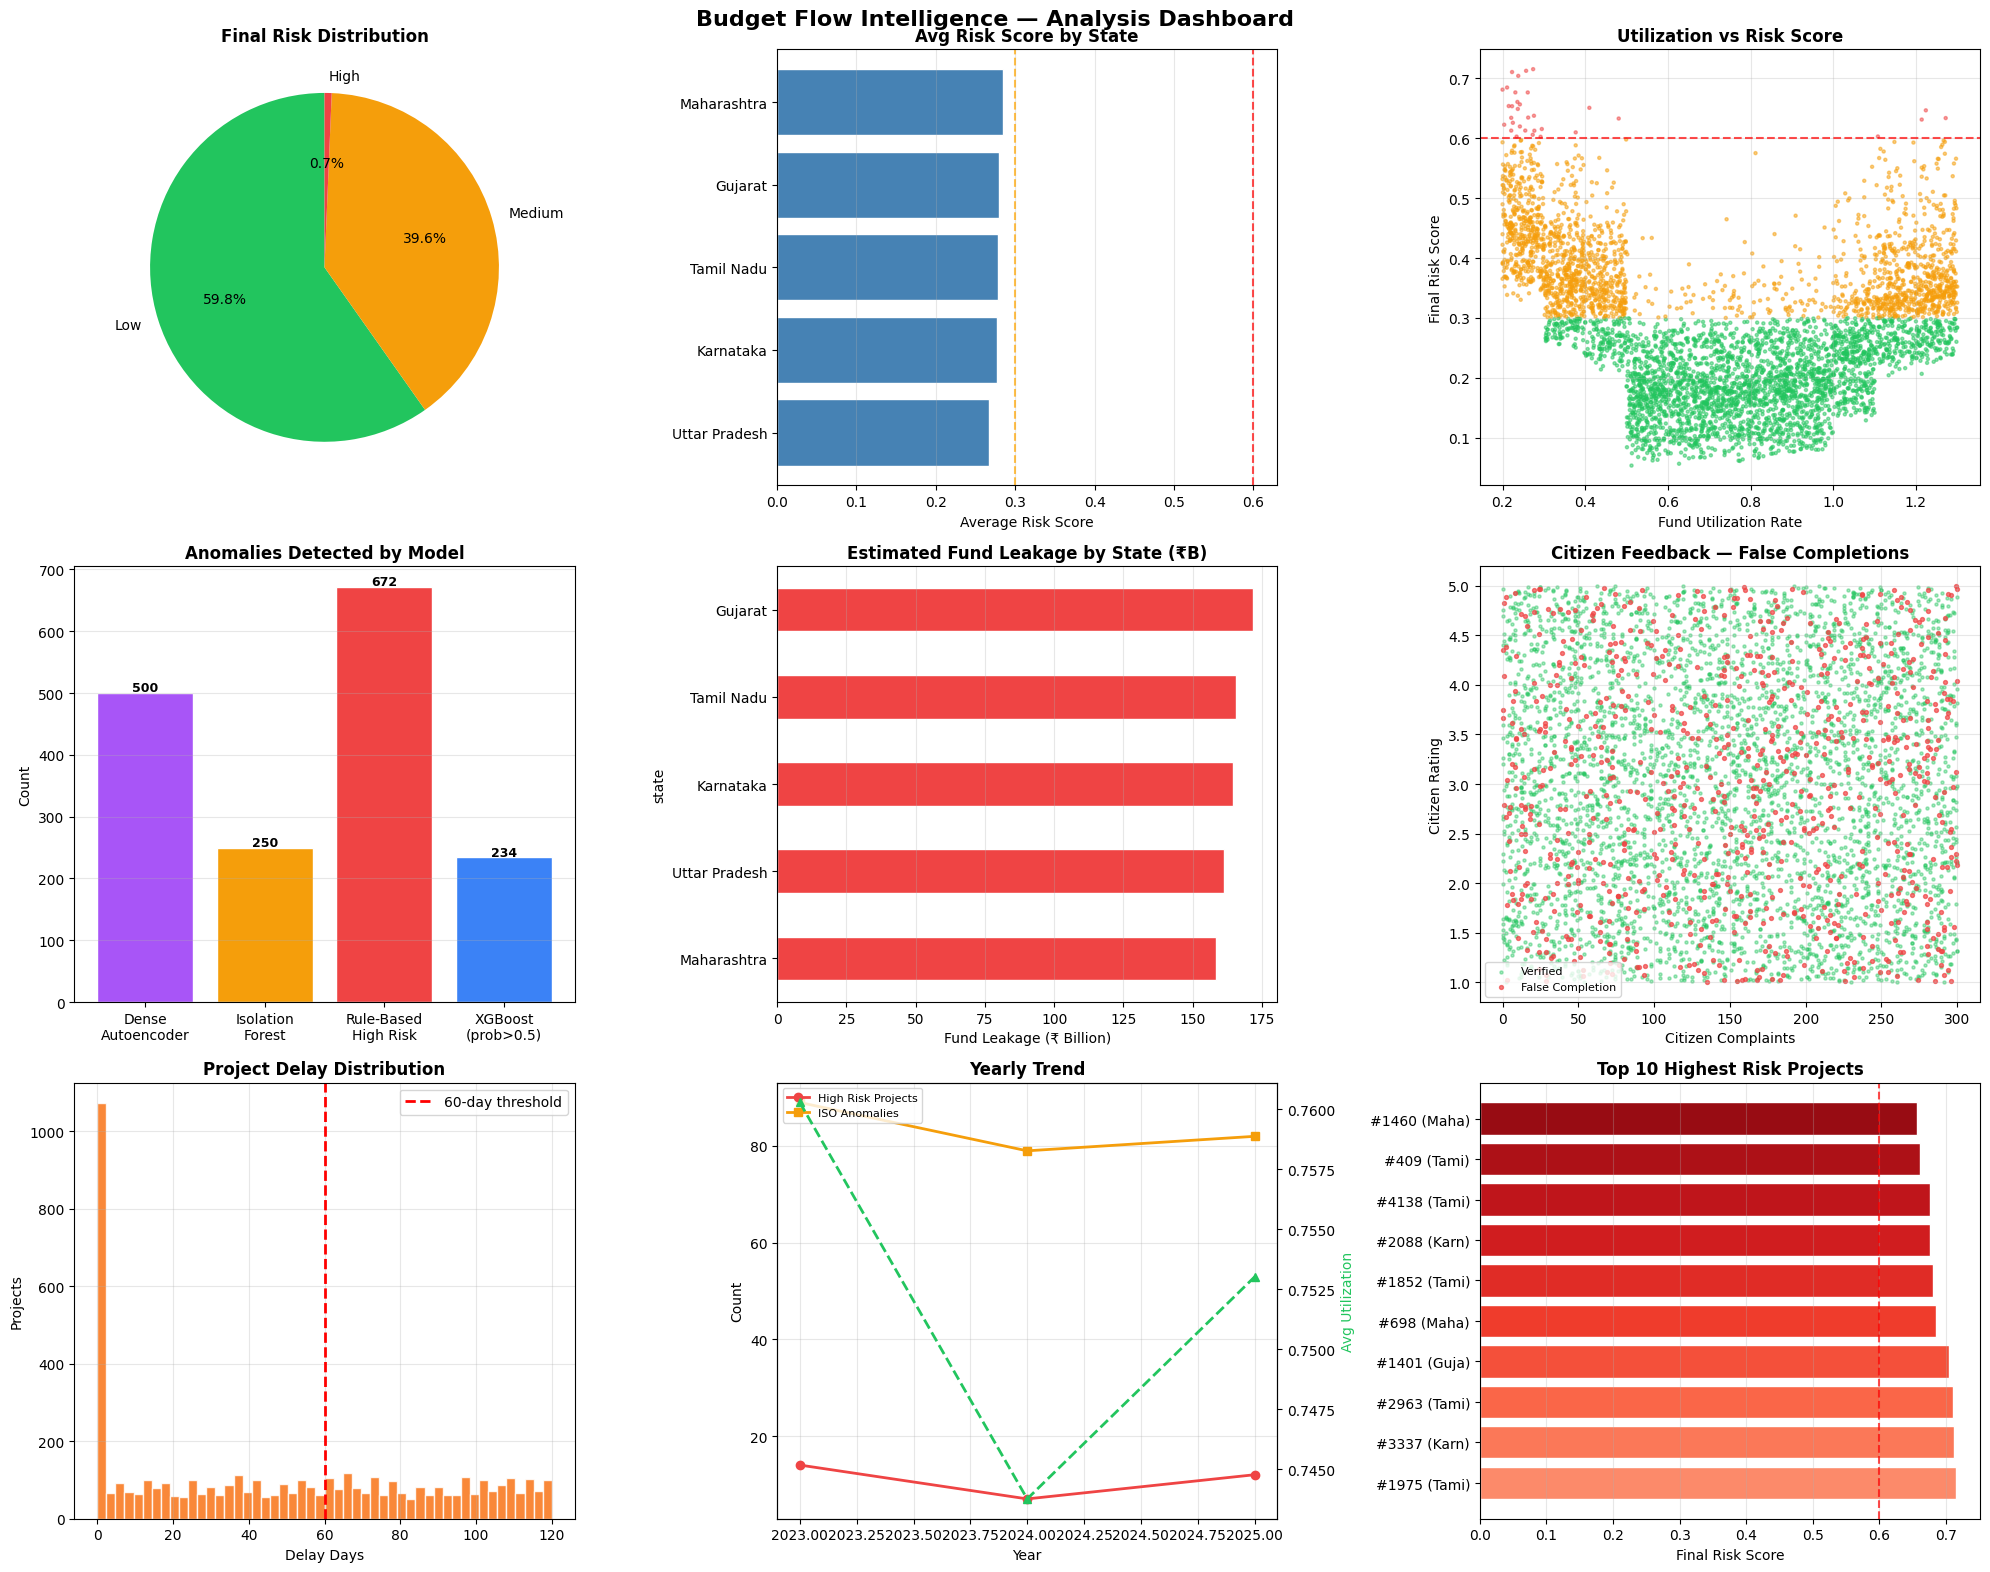

✅ Dashboard saved as 'budget_intelligence_dashboard.png'


In [27]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Budget Flow Intelligence — Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)

# 1. Risk Distribution Pie
ax1 = fig.add_subplot(3, 3, 1)
risk_counts = df['final_risk_label'].value_counts()
colors_pie = ['#22c55e', '#f59e0b', '#ef4444']
ax1.pie(risk_counts.values, labels=risk_counts.index, colors=colors_pie,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax1.set_title('Final Risk Distribution', fontweight='bold')

# 2. Risk by State
ax2 = fig.add_subplot(3, 3, 2)
state_risk = df.groupby('state')['final_risk_score'].mean().sort_values()
bars = ax2.barh(state_risk.index, state_risk.values, color='steelblue', edgecolor='white')
ax2.set_title('Avg Risk Score by State', fontweight='bold')
ax2.set_xlabel('Average Risk Score')
ax2.axvline(0.3, color='orange', linestyle='--', alpha=0.7)
ax2.axvline(0.6, color='red', linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3, axis='x')

# 3. Fund Utilization vs Risk Score
ax3 = fig.add_subplot(3, 3, 3)
scatter_colors = ['#22c55e' if r == 'Low' else '#f59e0b' if r == 'Medium' else '#ef4444'
                  for r in df['final_risk_label']]
ax3.scatter(df['fund_utilization_rate'], df['final_risk_score'],
            c=scatter_colors, s=5, alpha=0.5)
ax3.set_xlabel('Fund Utilization Rate')
ax3.set_ylabel('Final Risk Score')
ax3.set_title('Utilization vs Risk Score', fontweight='bold')
ax3.axhline(0.6, color='red', linestyle='--', alpha=0.7)
ax3.grid(True, alpha=0.3)

# 4. Anomalies by Model
ax4 = fig.add_subplot(3, 3, 4)
model_anomalies = {
    'Dense\nAutoencoder': df['ae_anomaly'].sum(),
    'Isolation\nForest': df['iso_anomaly'].sum(),
    'Rule-Based\nHigh Risk': (df['risk_score'] > 0.6).sum(),
    'XGBoost\n(prob>0.5)': (df['xgb_anomaly_prob'] > 0.5).sum()
}
bars = ax4.bar(model_anomalies.keys(), model_anomalies.values(),
               color=['#a855f7', '#f59e0b', '#ef4444', '#3b82f6'], edgecolor='white')
for bar, val in zip(bars, model_anomalies.values()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val),
             ha='center', fontsize=9, fontweight='bold')
ax4.set_title('Anomalies Detected by Model', fontweight='bold')
ax4.set_ylabel('Count')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Fund Leakage by State
ax5 = fig.add_subplot(3, 3, 5)
leakage = df.groupby('state').apply(
    lambda g: (g['central_allocated_funds'] - g['district_received_funds']).sum() / 1e9)
leakage.sort_values().plot(kind='barh', ax=ax5, color='#ef4444', edgecolor='white')
ax5.set_title('Estimated Fund Leakage by State (₹B)', fontweight='bold')
ax5.set_xlabel('Fund Leakage (₹ Billion)')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Citizen Rating vs Complaints (false completions highlighted)
ax6 = fig.add_subplot(3, 3, 6)
normal = df[df['false_completion'] == 0]
false_c = df[df['false_completion'] == 1]
ax6.scatter(normal['citizen_complaints'], normal['citizen_rating'],
            s=5, alpha=0.4, color='#22c55e', label='Verified')
ax6.scatter(false_c['citizen_complaints'], false_c['citizen_rating'],
            s=8, alpha=0.7, color='#ef4444', label='False Completion')
ax6.set_xlabel('Citizen Complaints')
ax6.set_ylabel('Citizen Rating')
ax6.set_title('Citizen Feedback — False Completions', fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Delay Distribution
ax7 = fig.add_subplot(3, 3, 7)
ax7.hist(df['delay_days'].clip(-30, 200), bins=50, color='#f97316', edgecolor='white', alpha=0.85)
ax7.axvline(60, color='red', linestyle='--', linewidth=2, label='60-day threshold')
ax7.set_title('Project Delay Distribution', fontweight='bold')
ax7.set_xlabel('Delay Days')
ax7.set_ylabel('Projects')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Yearly Trend
ax8 = fig.add_subplot(3, 3, 8)
yearly = df.groupby('year').agg(
    avg_util=('fund_utilization_rate', 'mean'),
    high_risk=('final_risk_score', lambda x: (x > 0.6).sum()),
    iso_anom=('iso_anomaly', 'sum')
).reset_index()
ax8.plot(yearly['year'], yearly['high_risk'], 'o-', color='#ef4444', linewidth=2, label='High Risk Projects')
ax8.plot(yearly['year'], yearly['iso_anom'], 's-', color='#f59e0b', linewidth=2, label='ISO Anomalies')
ax8b = ax8.twinx()
ax8b.plot(yearly['year'], yearly['avg_util'], '^--', color='#22c55e', linewidth=2, label='Avg Utilization')
ax8b.set_ylabel('Avg Utilization', color='#22c55e')
ax8.set_title('Yearly Trend', fontweight='bold')
ax8.set_xlabel('Year')
ax8.set_ylabel('Count')
ax8.legend(loc='upper left', fontsize=8)
ax8.grid(True, alpha=0.3)

# 9. Top 10 High Risk Projects
ax9 = fig.add_subplot(3, 3, 9)
top10 = df.nlargest(10, 'final_risk_score')[['record_id', 'final_risk_score', 'state']]
colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, 10))
bars = ax9.barh([f"#{r['record_id']} ({r['state'][:4]})" for _, r in top10.iterrows()],
                top10['final_risk_score'], color=colors_bar, edgecolor='white')
ax9.set_title('Top 10 Highest Risk Projects', fontweight='bold')
ax9.set_xlabel('Final Risk Score')
ax9.axvline(0.6, color='red', linestyle='--', alpha=0.7)
ax9.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("budget_intelligence_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'budget_intelligence_dashboard.png'")



In [34]:
print("=" * 60)
print("💾 SAVING RESULTS & MODELS")
print("=" * 60)

# Save enriched dataset
output_cols = list(df.columns) + [
    'ae_recon_error','ae_anomaly','iso_anomaly','iso_score',
    'lapse_probability','xgb_anomaly_prob',
    'final_risk_score','final_risk_label'
]

output_cols = list(dict.fromkeys(output_cols))

df_out = df[[c for c in output_cols if c in df.columns]]

df_out.to_csv("../data/budget_results_with_risk_scores.csv", index=False)
print("✅ Results saved → ml/data/budget_results_with_risk_scores.csv")

# Save high-risk alerts
high_risk_df = df_out[df_out['final_risk_label']=="High"].sort_values("final_risk_score",ascending=False)

high_risk_df.to_csv("../data/high_risk_projects.csv", index=False)

print(f"✅ High-risk projects saved → ({len(high_risk_df)} records)")

# Save vendor risk report
vendor_risk.sort_values(
    "vendor_risk_score",ascending=False
).to_csv("../data/vendor_risk_report.csv", index=False)

print("✅ Vendor risk report saved")

# Save ML models
import joblib

joblib.dump(rf_model,"../model/model_random_forest.pkl")
joblib.dump(xgb_model,"../model/model_xgboost.pkl")
joblib.dump(iso_forest,"../model/model_isolation_forest.pkl")
joblib.dump(autoencoder,"../model/model_autoencoder.pkl")
joblib.dump(scaler,"../model/feature_scaler.pkl")

print("✅ All models saved → ml/model/")

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE — SUMMARY")
print("=" * 60)

print(f"Total Projects Analyzed : {len(df):,}")
print(f"Dense AE Flags          : {df['ae_anomaly'].sum():,}")
print(f"Isolation Forest Flags  : {df['iso_anomaly'].sum():,}")
print(f"High Lapse Probability  : {(df['lapse_probability'] > 0.6).sum():,}")
print(f"Final HIGH RISK Count   : {(df['final_risk_label']=='High').sum():,}")
print(f"Final MEDIUM RISK Count : {(df['final_risk_label']=='Medium').sum():,}")
print(f"Final LOW RISK Count    : {(df['final_risk_label']=='Low').sum():,}")
print(f"False Completions Found : {df['false_completion'].sum():,}")
print(f"High-Risk Vendors       : {(vendor_risk['vendor_risk_label']=='High').sum():,}")

print("=" * 60)

💾 SAVING RESULTS & MODELS
✅ Results saved → ml/data/budget_results_with_risk_scores.csv
✅ High-risk projects saved → (33 records)
✅ Vendor risk report saved
✅ All models saved → ml/model/

🎉 TRAINING COMPLETE — SUMMARY
Total Projects Analyzed : 5,000
Dense AE Flags          : 500
Isolation Forest Flags  : 250
High Lapse Probability  : 1,354
Final HIGH RISK Count   : 33
Final MEDIUM RISK Count : 1,978
Final LOW RISK Count    : 2,989
False Completions Found : 804
High-Risk Vendors       : 3
